# Can polls call Senate winners? (train '08–'12, test '14)

Third in the series on the
[OS_election](https://github.com/903124/OS_election) data. The question:
take every Senate race's final polling and turn it into a **win rate** — a
probability the race's candidate wins — under a polling-error model in which
misses are **correlated across states**, then score the full 2014 map
against what actually happened.

Why correlated: election-night polling misses don't strike states at
random. A cycle where polls understate one party in Colorado tends to
understate it in Iowa and Kansas too — a national-mood component every
state shares, sitting on top of each state's own idiosyncratic miss. A
model that pretends state errors are independent therefore double-counts
certainty: race-by-race favorites look safer than they are, and the
seat-count distribution comes out much tighter than election night ever
feels. The fix here is the classic two-level structure:

- **poll margin → predicted margin.** A recency-weighted final-3-weeks
  polling average (two-party), plus a small incumbency bump estimated from
  the training years. The presidential lean backstops races the polls
  skipped.
- **error = national + state.** Each simulated election night draws one
  shared national shock `N(μ_nat, σ_nat²)` plus an independent state shock
  `N(0, σ_state²)` per race. Both parameters come from the 2008, 2010 and
  2012 training races — the polling ("pred") tables against the results
  ("senate") tables.
- **win rate = P(margin > 0)** over 20,000 simulated election nights.

A second model runs alongside it: the **naive** one, which draws only the
state shock and skips the national term — that is what "the states are
independent" buys you, and the comparison is the whole point of the
exercise.

Honest notes up front. Races are screened for competitiveness like notebook
02: a Republican on the ballot, a Democratic (or leading independent) one
opposite, and the loser above 5% of the two-party vote — a walkover measures
the filing deadline, not the polls. Georgia 2008 and Louisiana 2014 were
decided by runoffs, so the runoff box and runoff day are what count there.
Kansas's Democrat quit the race, so its "left" candidate is independent Greg
Orman (Vermont 2012 is Bernie Sanders, same treatment); a Kansas win counts
toward neither party in the seat tally. Fusion-party lines are summed within
each candidate, the results export's stray convention and embedded-poll
tables are dropped by construction, and Alaska has no presidential lean
because the pipeline ships no county-level presidential data for it.

| thing | comes from |
|---|---|
| results (targets) | `data/senate/senate_general_results_{2008,2010,2012,2014}.csv` |
| polls (predictors) | `data/senate/senate_general_polling_{2008,2010,2012,2014}.csv` |
| presidential lean | `data/presidential/presidential_results_{2008,2012}.csv` |

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path("../OS_election")
if not (REPO / "data").exists():          # notebook lives inside the repo
    REPO = Path("..")

pd.options.display.float_format = "{:.1f}".format
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11,
})
PARTY_COLOR = {"d": "#2a6fdb", "r": "#d94040", "o": "#7a5195"}
YEAR_COLOR = {2008: "#9ecae1", 2010: "#4292c6", 2012: "#08519c", 2014: "#9a9a9a"}

TRAIN_YEARS = [2008, 2010, 2012]
TEST_YEAR = 2014
YEARS = TRAIN_YEARS + [TEST_YEAR]
ELECTION_DAY = {2008: "2008-11-04", 2010: "2010-11-02",
                2012: "2012-11-06", 2014: "2014-11-04"}
# two seats were decided by a later runoff — that runoff is the race
DATE_OVERRIDE = {(2008, "Georgia"): "2008-12-02",
                 (2014, "Louisiana"): "2014-12-06"}
BOX_OVERRIDE = {(2008, "Georgia"): "Runoff results"}
# the MS-2008 special was legally nonpartisan and wiki drops the party
# labels; restore them so Wicker (R) vs Musgrove (D) stays in training
PARTY_FIX = {(2008, "Mississippi (special)"): {"roger wicker": "r",
                                               "ronnie musgrove": "d"}}

WINDOW_DAYS, HALF_LIFE_DAYS, DEFAULT_SAMPLE = 21, 7.0, 600
SIMS, SEED = 20_000, 2014

def party_class(p):
    # wiki ships long forms: "Republican Party of Minnesota",
    # "Minnesota Democratic–Farmer–Labor Party", "Democratic Party (Alabama)"
    p = str(p or "").strip().lower()
    return "d" if re.search(r"democratic|dfl", p) else "r" if "republican" in p else "o"

def num(s):  # "2,100 (LV)" -> 2100.0
    digits = re.sub(r"[^\d]", "", str(s or ""))
    return float(digits) if digits else np.nan

warnings.simplefilter("ignore")
print("pandas", pd.__version__)

pandas 2.2.3


## 1 · The races (what has to be predicted)

Each results CSV is candidate-per-election-box. A box becomes a race when it
survives four filters: no "Undecided" line (that's an embedded poll table —
2012 California ships two of them), a Republican present (kills primary-era
convention tables), a named candidate above the walkover screen, and — for
the 2008/2012 multi-certification states — the final box wins. The **left**
candidate is the top Democrat, or the top independent when no Democrat ran
(Kansas 2014, Vermont 2012). The margin the model predicts everywhere below
is `100 · (left − right) / (left + right)`: two-party points, positive = D
side ahead.

In [2]:
def build_races(year):
    res = pd.read_csv(REPO / f"data/senate/senate_general_results_{year}.csv")
    rows, dropped = [], []
    for (state, election), box in res.groupby(["State", "Election"], sort=False):
        label = f"{year} {state}"
        if BOX_OVERRIDE.get((year, state), election) != election:
            dropped.append((label, "not the race box (runoff override)"))
            continue
        cand = box[box["Row_Type"].isin(["Winning", "Candidate"])].copy()
        if (cand.empty or (cand["candidate"].astype(str)
                           .str.strip().str.lower() == "undecided").any()):
            dropped.append((label, "embedded poll table"))
            continue
        cand["key"] = (cand["candidate"].astype(str)
                       .str.replace(r"\s*\(write-in\)\s*$", "", regex=True)
                       .str.strip().str.lower())
        cand["pc"] = cand["party"].map(party_class)
        for fix_cand, fix_pc in PARTY_FIX.get((year, state), {}).items():
            cand.loc[cand.key == fix_cand, "pc"] = fix_pc
        if "r" not in set(cand["pc"]):
            dropped.append((label, "no Republican (convention table?)"))
            continue
        cand["votes_n"] = cand["votes"].map(num)
        # fusion ballots: one person, several party lines -> sum the votes
        agg = (cand.groupby("key", as_index=False)
               .agg(votes=("votes_n", "sum"), pc=("pc", "first"),
                    inc=("Incumbent", "max"), name=("candidate", "first")))
        d_row = agg[agg.pc == "d"].nlargest(1, "votes")
        r_row = agg[agg.pc == "r"].nlargest(1, "votes")
        left = d_row if len(d_row) else agg[agg.pc == "o"].nlargest(1, "votes")
        if not len(left) or not len(r_row):
            dropped.append((label, "no left candidate"))
            continue
        L, R = left.iloc[0], r_row.iloc[0]
        two, loser = L.votes + R.votes, min(L.votes, R.votes)
        if loser / two < 0.05:
            dropped.append((label, "walkover (<5% of two-party vote)"))
            continue
        rows.append({
            "year": year, "state": state,
            "election_day": pd.Timestamp(DATE_OVERRIDE.get((year, state), ELECTION_DAY[year])),
            "left_name": str(L["name"]).title().strip(),
            "left_party": L.pc, "left_inc": bool(L.inc),
            "right_name": str(R["name"]).title().strip(), "right_inc": bool(R.inc),
            "margin": 100 * (L.votes - R.votes) / two,
        })
    df = pd.DataFrame(rows)
    if len(df):
        df = df.drop_duplicates(["year", "state"], keep="last")  # final certified box
    return df, dropped

frames, drop_log = [], {}
for y in YEARS:
    df, drops = build_races(y)
    frames.append(df)
    drop_log[y] = drops
races = pd.concat(frames, ignore_index=True)

for y in YEARS:
    print(f"{y}: {len(drop_log[y])} boxes dropped -> "
          f"{(races.year == y).sum()} races kept")
print()
for y in YEARS:
    for label, why in drop_log[y]:
        print(f"  {label:28s} {why}")

print("\nleft candidates that are not Democrats:")
print(races.loc[races.left_party != "d",
                ["year", "state", "left_name", "left_party"]].to_string(index=False))

2008: 2 boxes dropped -> 34 races kept
2010: 3 boxes dropped -> 36 races kept
2012: 9 boxes dropped -> 33 races kept
2014: 2 boxes dropped -> 35 races kept

  2008 Arkansas                no Republican (convention table?)
  2008 Georgia                 not the race box (runoff override)
  2010 Connecticut             no left candidate
  2010 South Dakota            no left candidate
  2010 Utah                    no Republican (convention table?)
  2012 California              embedded poll table
  2012 California              embedded poll table
  2012 Massachusetts           no Republican (convention table?)
  2012 Texas                   no left candidate
  2012 Texas                   no Republican (convention table?)
  2012 Texas                   no Republican (convention table?)
  2012 Utah                    no left candidate
  2012 Utah                    no left candidate
  2012 Utah                    no Republican (convention table?)
  2014 Alabama                 no left c

**138 races** survived: 34 + 36 + 33 + 35. The casualties are exactly what
should fall — unopposed incumbents (Pryor '08, Thune '10), a state that
fielded no Democrat (Alabama '14), convention tables, and the two
California poll tables that leaked into the results export. Every state
with a real contest is in, including both 2014 South Carolina races and the
Oklahoma/Hawaii specials, which the pipeline disambiguates with a
`(special)` suffix on the state name.

## 2 · The polls (the predictors)

The polling CSV is candidate-per-poll-row with party codes that can't be
trusted ("Al Franken (DFL)" ships as `Unknown`), whole-number percentages,
and free-text dates. Three fixes before averaging:

1. **Match polls to races by surname** — strip any `(party)` suffix, take
   the last token, and keep only rows naming the race's two candidates.
   This silently discards hypothetical matchups (the five Democrats polled
   against each other in Kansas) and primary names (Milton Wolf), and it
   splits shared states cleanly.
2. **One poll instance = one pollster + one field date** — a poll reports
   both candidates' percentages; the two-party margin is
   `100 · (L − R) / (L + R)`, third parties excluded from the denominator,
   exactly mirroring the results side.
3. **Recency-weight, 538-style** — keep polls fielded in the last 21 days,
   weight by `0.5^(days_old/7) · √n` (7-day half-life, √sample-size,
   default n=600 when unreported). The final average is the weighted mean
   of poll margins.

In [3]:
def load_polls(year):
    p = pd.read_csv(REPO / f"data/senate/senate_general_polling_{year}.csv")
    p["pct"] = p["Pct"].astype(str).str.rstrip("%").astype(float)
    p["n"] = p["Sample"].map(num).fillna(DEFAULT_SAMPLE)
    p["end"] = pd.to_datetime(p["Date_End"], errors="coerce")
    return p.dropna(subset=["end"])

def surname(name):
    # strip party suffixes: "Al Franken (DFL)", "Heidi Heitkamp (D-NPL)"
    return re.sub(r"\s*\(.*\)$", "", str(name).strip()).upper().split()[-1]

def poll_margin(race, polls):
    ps = polls[polls["State"] == race.state].copy()
    if ps.empty:
        return np.nan, 0, 0
    sl, sr = surname(race.left_name), surname(race.right_name)
    if sl == sr:
        return np.nan, 0, 0
    ps["side"] = ps["Candidate"].map(surname).map({sl: "L", sr: "R"})
    ps = ps[ps["side"].notna() & ps["pct"].notna()]
    ps["Date_Start"] = ps["Date_Start"].fillna("")
    inst = ps.pivot_table(index=["Poll_Source", "Date_Start", "end", "n"],
                          columns="side", values="pct", aggfunc="mean")
    if not {"L", "R"} <= set(inst.columns):
        return np.nan, 0, 0
    inst = inst.dropna(subset=["L", "R"])
    elec = race.election_day
    end = inst.index.get_level_values("end")
    inst = inst[(end >= elec - pd.Timedelta(days=WINDOW_DAYS)) & (end <= elec)]
    if not len(inst):
        return np.nan, 0, 0
    end = inst.index.get_level_values("end")
    days = np.asarray((elec - end).days, dtype=float)
    ns = np.asarray(inst.index.get_level_values("n"), dtype=float)
    w = 0.5 ** (days / HALF_LIFE_DAYS) * np.sqrt(ns)
    L, R = inst["L"].values, inst["R"].values
    m = 100 * (L - R) / (L + R)
    return float((m * w).sum() / w.sum()), len(inst), float(ns.sum())

poll_tables = {y: load_polls(y) for y in YEARS}
pm = races.apply(lambda r: poll_margin(r, poll_tables[r.year]), axis=1)
races[["poll_margin", "n_polls", "n_respondents"]] = pd.DataFrame(pm.tolist(),
                                                                  index=races.index)

cov = races.groupby("year").agg(
    races=("state", "count"), with_polls=("poll_margin", lambda s: s.notna().sum()),
    mean_polls=("n_polls", "mean"))
print("final-window coverage by year:")
print(cov.to_string())

print("\nraces the polls skipped:")
nopoll = races[races.poll_margin.isna()]
for y, grp in nopoll.groupby("year"):
    print(f"  {y}: {', '.join(grp.state)}")

final-window coverage by year:
      races  with_polls  mean_polls
year                               
2008     34          24         2.6
2010     36          33         5.4
2012     33          27         5.0
2014     35          34         5.8

races the polls skipped:
  2008: Alabama, Delaware, Idaho, Illinois, Massachusetts, Michigan, Mississippi, Nebraska, Rhode Island, South Dakota
  2010: Alabama, Massachusetts (special), Oklahoma
  2012: Delaware, Mississippi, Tennessee, Vermont, West Virginia, Wyoming
  2014: South Dakota


biggest competitive 2014 misses: Arkansas (-6 -> -18), Kansas (+0 -> -11), Virginia (+9 -> +1)


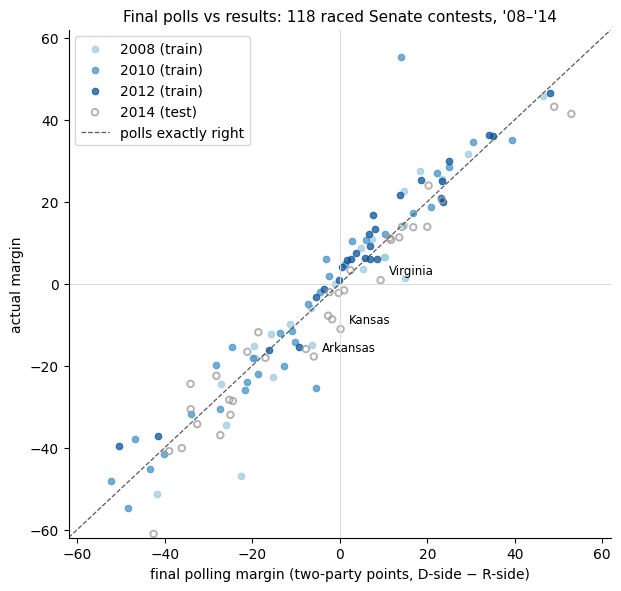

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 6.6))
for y in YEARS:
    sub = races[(races.year == y) & races.poll_margin.notna()]
    is_test = y == TEST_YEAR
    ax.scatter(sub.poll_margin, sub.margin, s=22, alpha=0.75,
               facecolor="none" if is_test else YEAR_COLOR[y],
               edgecolor=YEAR_COLOR[y], linewidth=1.4 if is_test else 0.8,
               label=f"{y} ({'test' if is_test else 'train'})")
lim = 62
ax.plot([-lim, lim], [-lim, lim], color="0.35", lw=0.9, ls="--", label="polls exactly right")
ax.plot([-lim, lim], [0, 0], color="0.85", lw=0.7)
ax.plot([0, 0], [-lim, lim], color="0.85", lw=0.7)
ax.set(xlabel="final polling margin (two-party points, D-side − R-side)",
       ylabel="actual margin", xlim=(-lim, lim), ylim=(-lim, lim),
       title="Final polls vs results: 118 raced Senate contests, '08–'14")
ax.legend(loc="upper left")

# label the competitive 2014 misses
test_err = (races.year == TEST_YEAR) & races.poll_margin.notna() & (races.margin.abs() < 20)
big3 = races[test_err].assign(e=lambda d: (d.margin - d.poll_margin).abs()).nlargest(3, "e")
for _, r in big3.iterrows():
    ax.annotate(r.state, (r.poll_margin, r.margin), fontsize=8.5,
                xytext=(6, 4), textcoords="offset points")
print("biggest competitive 2014 misses:",
      ", ".join(f"{r.state} ({r['poll_margin']:+.0f} -> {r.margin:+.0f})"
                for _, r in big3.iterrows()))

The training years hug the diagonal — the final-poll average is a genuinely
good margin predictor, good enough that the interesting question is only
the *shape of the miss*. The 2014 hollow points already hint at the answer:
Virginia and Kansas sit far below the line (polls ran D-hot), and the
misses have the same sign in several states at once. Quantifying that is
sections 4 and 5.

## 3 · The presidential lean (the fundamentals backstop)

One race in 2014 — South Dakota — has no final-window polls, and a
seat-count model can't leave a seat blank. The backstop is the state's
presidential two-party margin: same-year for 2008/2012 races, the most
recent presidential year for midterms (2008 for 2010, 2012 for 2014). It's
built here from the county-level presidential CSVs — sum D-family votes
(including DFL/D-NPL) and Republican votes per state — which reproduces the
familiar map with no external data. A slope/intercept fit on the training
races calibrates presidential margin to Senate margin, because Senate races
run a couple of points more Republican than the top of the ticket.

races with no presidential lean: ['2008 Alaska', '2010 Alaska', '2014 Alaska']
lean -> actual margin (train): margin = 0.89 * lean -2.6,  r2 = 0.45


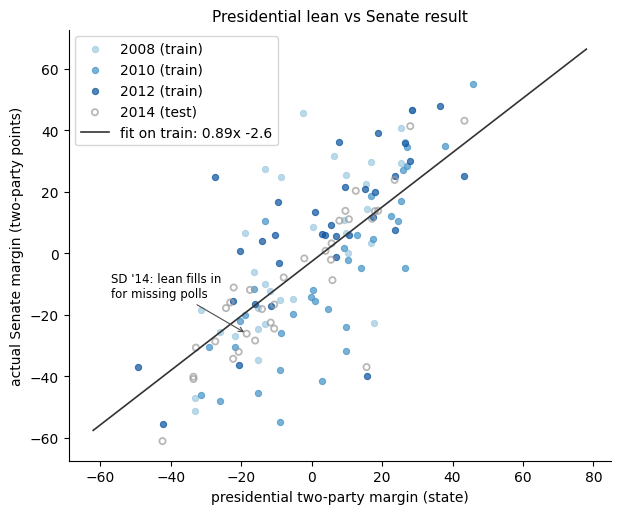

In [5]:
PRES = pd.concat([pd.read_csv(REPO / f"data/presidential/presidential_results_{y}.csv")
                  for y in (2008, 2012)])
PRES["pc"] = PRES["party"].map(party_class)
STATE_CODE = dict(PRES[["state", "state_code"]].drop_duplicates().values)
tot = PRES.groupby(["year", "state_code", "pc"])["votes"].sum().unstack()
lean = (100 * (tot["d"] - tot["r"]) / (tot["d"] + tot["r"])).unstack("year")

def lean_of(row):
    py = row.year if row.year in lean.columns else max(
        y for y in lean.columns if y < row.year)
    code = STATE_CODE.get(re.sub(r"\s*\(special\)$", "", row.state))
    try:
        return lean.loc[code, py]
    except KeyError:
        return np.nan      # Alaska: no county presidential data in the pipeline

races["lean_margin"] = races.apply(lean_of, axis=1)
print("races with no presidential lean:",
      [f"{r.year} {r.state}" for _, r in races[races.lean_margin.isna()].iterrows()])

train = races[(races.year.isin(TRAIN_YEARS)) & races.poll_margin.notna()].copy()
fit = train.dropna(subset=["lean_margin"])
b_lean = np.polyfit(fit.lean_margin, fit.margin, 1)
r2 = np.corrcoef(fit.lean_margin, fit.margin)[0, 1] ** 2
print(f"lean -> actual margin (train): margin = {b_lean[0]:.2f} * lean {b_lean[1]:+.1f},  r2 = {r2:.2f}")
races["lean_pred"] = b_lean[0] * races.lean_margin + b_lean[1]

fig, ax = plt.subplots(figsize=(7.0, 5.6))
for y in YEARS:
    sub = races[(races.year == y) & races.lean_margin.notna()]
    is_test = y == TEST_YEAR
    ax.scatter(sub.lean_margin, sub.margin, s=20, alpha=0.7,
               facecolor="none" if is_test else YEAR_COLOR[y],
               edgecolor=YEAR_COLOR[y], linewidth=1.3 if is_test else 0.8,
               label=f"{y} ({'test' if is_test else 'train'})")
xs = np.linspace(-62, 78, 50)
ax.plot(xs, np.polyval(b_lean, xs), color="0.2", lw=1.2,
        label=f"fit on train: {b_lean[0]:.2f}x {b_lean[1]:+.1f}")
sd = races[(races.state == "South Dakota") & (races.year == 2014)].iloc[0]
ax.annotate("SD '14: lean fills in\nfor missing polls", (sd.lean_margin, sd.margin),
            fontsize=8.5, xytext=(-98, 26), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="0.3", lw=0.8))
ax.set(xlabel="presidential two-party margin (state)",
       ylabel="actual Senate margin (two-party points)",
       title="Presidential lean vs Senate result")
ax.legend(loc="upper left");

## 4 · What polls miss, and how it travels

Define the race-level error as

```
err = actual margin − (final poll margin + incumbency bump)
```

The **incumbency bump** comes first, estimated on the training races with
year effects removed so it can't soak up cycle-wide mood: it lands at
**+1.55 points** for the side holding the seat — D-held and R-held races
aloud alike, the incumbent party out-ran its polls. What's left is the
polling error proper, and it splits into two layers by construction:

- the **year mean** — how far all of a cycle's polls leaned together. That
  is the realized *national error*, one draw per cycle: −1.1 in 2008,
  +1.7 in 2010, +1.8 in 2012 (positive = the D side out-ran the polls).
- the **within-year spread** — how far a race missed its own cycle's mean.
  That is the *state error*, pooled sd ≈ 7.2 points.

The two-level variance decomposition is method-of-moments: the pooled
within-year variance estimates `σ_state²` directly, and the (unweighted)
variance of the three year means estimates `σ_nat² + σ_state²/n̄` — subtract
the estimation noise and you get `σ_nat²`. With three cycles the raw
estimate comes out under one point, i.e. statistically indistinguishable
from zero — no three-cycle panel can resolve a between-year component this
small — so the model floors `σ_nat` at **2 points**, roughly the smallest
national error any realistic cycle produces, and section 5 shows how the
tails respond to 0/2/4. The correlation this implies between two states'
errors is `σ_nat² / (σ_nat² + σ_state²)` ≈ 0.07: modest, and honest —
Senate polling error is dominated by state-level noise, not national
swing.

incumbency bump (D-side framing): +1.55 points

error = actual - (poll + bump), by year:
       n  mean_err  sd_err  se_err
year                              
2008  24      -1.1     7.2     1.5
2010  33       1.7     9.0     1.6
2012  27       1.8     4.1     0.8

national: mean +0.93, sigma raw 0.91 -> floored 2.00
state:    sigma 7.20
implied pairwise error correlation between states: 0.07


[[<matplotlib.axis.XTick at 0x7fba99216150>,
 Text(0.5, 0, 'cycle'),
 Text(0, 0.5, 'error (points, D-side)'),
 Text(0.5, 1.0, '84 training races: polling error splits into a year mean + state noise')]

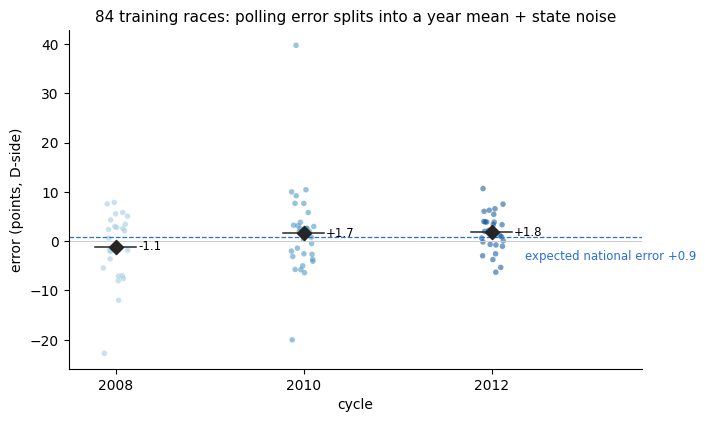

In [6]:
inc_sign = np.where(train.left_inc & ~train.right_inc, 1.0,
                    np.where(train.right_inc & ~train.left_inc, -1.0, 0.0))
train["inc"] = inc_sign
e0 = train.margin - train.poll_margin
e0d = e0 - e0.groupby(train.year).transform("mean")   # year-demeaned
BETA_INC = float(np.clip((e0d * inc_sign).sum() / (inc_sign ** 2).sum(), -2.5, 2.5))
train["pred_margin"] = train.poll_margin + BETA_INC * train.inc
train["err"] = train.margin - train.pred_margin
print(f"incumbency bump (D-side framing): {BETA_INC:+.2f} points")

yr = train.groupby("year").agg(n=("err", "size"), mean_err=("err", "mean"),
                               sd_err=("err", "std"))
yr["se_err"] = yr.sd_err / np.sqrt(yr.n)
print("\nerror = actual - (poll + bump), by year:")
print(yr.to_string())

mu_y = train.groupby("year")["err"].mean()
n_y = train.groupby("year")["err"].size()
s2_y = train.groupby("year")["err"].var(ddof=1)
w = n_y / n_y.sum()
NAT_MEAN = float((w * mu_y).sum())
s2_state = float(((n_y - 1) * s2_y).sum() / (n_y - 1).sum())
s2_mu = float(((mu_y - mu_y.mean()) ** 2).sum() / (len(n_y) - 1))
s2_nat_raw = s2_mu - s2_state * float((1 / n_y).mean())
SIGMA_NAT_FLOOR = 2.0
SIGMA_NAT = max(np.sqrt(max(s2_nat_raw, 0.0)), SIGMA_NAT_FLOOR)
SIGMA_STATE = np.sqrt(s2_state)
print(f"\nnational: mean {NAT_MEAN:+.2f}, sigma raw {np.sqrt(max(s2_nat_raw, 0.0)):.2f}"
      f" -> floored {SIGMA_NAT:.2f}")
print(f"state:    sigma {SIGMA_STATE:.2f}")
print(f"implied pairwise error correlation between states: "
      f"{SIGMA_NAT**2 / (SIGMA_NAT**2 + SIGMA_STATE**2):.2f}")

# the picture: errors by year, year means marked
fig, ax = plt.subplots(figsize=(7.4, 4.4))
rng_jit = np.random.default_rng(7)
for y in TRAIN_YEARS:
    errs = train.loc[train.year == y, "err"]
    ax.scatter(y + rng_jit.uniform(-0.13, 0.13, len(errs)), errs, s=16,
               alpha=0.55, color=YEAR_COLOR[y], edgecolor="none")
    ax.scatter([y], [errs.mean()], marker="D", s=52, color="0.15", zorder=5)
    ax.plot([y - 0.22, y + 0.22], [errs.mean()] * 2, color="0.15", lw=1.1, zorder=4)
ax.axhline(0, color="0.8", lw=0.7)
ax.axhline(NAT_MEAN, color="#2a6fdb", lw=0.9, ls="--")
ax.annotate(f"expected national error {NAT_MEAN:+.1f}", (2012.35, NAT_MEAN - 2.6),
            fontsize=8.5, color="#2a6fdb", va="top")
ax.set_xlim(2007.5, 2013.6)
for y in TRAIN_YEARS:
    ax.annotate(f"{train.loc[train.year == y, 'err'].mean():+.1f}",
                (y + 0.24, train.loc[train.year == y, "err"].mean()),
                fontsize=8.5, va="center")
ax.set(xticks=TRAIN_YEARS, xlabel="cycle", ylabel="error (points, D-side)",
       title="84 training races: polling error splits into a year mean + state noise")


## 5 · Projecting 2014 (the test)

Now freeze everything fitted above — bump, variances, national mean, lean
slope — and simulate the 2014 map 20,000 times. Every simulated night:

1. draws **one** national error `N(+0.9, 2.0²)` — shared by all 35 races;
2. draws an independent `N(0, 7.2²)` per race;
3. adds both to each race's predicted margin and scores the left candidate
   by whether the sum clears zero.

A race's **win rate** is the fraction of nights it survives. The naive
model is identical except step 1 — no shared shock. South Dakota's margin
comes from the lean fit (polls skipped it); Kansas's left side is Greg
Orman, counted toward neither party in the D-seat tally.

In [7]:
test = races[races.year == TEST_YEAR].copy()
test["inc"] = np.where(test.left_inc & ~test.right_inc, 1.0,
                       np.where(test.right_inc & ~test.left_inc, -1.0, 0.0))
test["use_lean"] = test.poll_margin.isna()
test["pred_margin"] = np.where(test.use_lean, test.lean_pred,
                               test.poll_margin + BETA_INC * test.inc)
test["actual_win"] = test.margin > 0

rng = np.random.default_rng(SEED)
nat = rng.normal(NAT_MEAN, SIGMA_NAT, SIMS)
noise_c = rng.normal(0, SIGMA_STATE, (SIMS, len(test)))
margins_c = test.pred_margin.values[None, :] + nat[:, None] + noise_c
noise_n = rng.normal(0, SIGMA_STATE, (SIMS, len(test)))
margins_n = test.pred_margin.values[None, :] + noise_n
test["win_corr"] = (margins_c > 0).mean(axis=0)
test["win_naive"] = (margins_n > 0).mean(axis=0)
test["race_label"] = (test.state.str.replace(" (special)", "*", regex=False)
                      + ": " + test.left_name.str.split().str[-1]
                      + " (" + test.left_party.str.upper()
                      + ") v " + test.right_name.str.split().str[-1] + " (R)")

show = (test.sort_values("win_corr", ascending=False)
        [["race_label", "pred_margin", "win_corr", "win_naive", "margin"]].copy())
show["win_corr"] = show["win_corr"].map("{:.2f}".format)
show["win_naive"] = show["win_naive"].map("{:.2f}".format)
show["use_lean_s"] = test.sort_values("win_corr", ascending=False)["use_lean"].map(
    {True: " <- lean backstop", False: ""}).values
print(f"2014 win rates, correlated error model ({SIMS:,} sims, "
      f"nat ~ N({NAT_MEAN:+.1f}, {SIGMA_NAT:.0f}²), state ~ N(0, {SIGMA_STATE:.1f}²)):")
print(show.to_string(index=False))

2014 win rates, correlated error model (20,000 sims, nat ~ N(+0.9, 2²), state ~ N(0, 7.2²)):
                                race_label  pred_margin win_corr win_naive  margin        use_lean_s
         Hawaii*: Schatz (D) v Cavasso (R)         50.6     1.00      1.00    43.2                  
     Rhode Island: Reed (D) v Zaccaria (R)         52.9     1.00      1.00    41.4                  
           Oregon: Merkley (D) v Wehby (R)         24.9     1.00      1.00    20.4                  
      Massachusetts: Markey (D) v Herr (R)         21.8     1.00      1.00    23.9                  
            Delaware: Coons (D) v Wade (R)         21.5     1.00      1.00    13.9                  
         New Jersey: Booker (D) v Bell (R)         18.3     1.00      0.99    13.8                  
       Illinois: Durbin (D) v Oberweis (R)         15.1     0.98      0.98    11.3                  
           Michigan: Peters (D) v Land (R)         14.2     0.98      0.98    13.8                 

races where the two models disagree most:


  Georgia      corr 0.41 vs naive 0.35  (polls -2.7, actual -7.8)
  Kansas       corr 0.48 vs naive 0.42  (polls -1.4, actual -11.1)
  Iowa         corr 0.46 vs naive 0.40  (polls -1.7, actual -8.7)
  Colorado     corr 0.51 vs naive 0.46  (polls -0.8, actual -2.1)


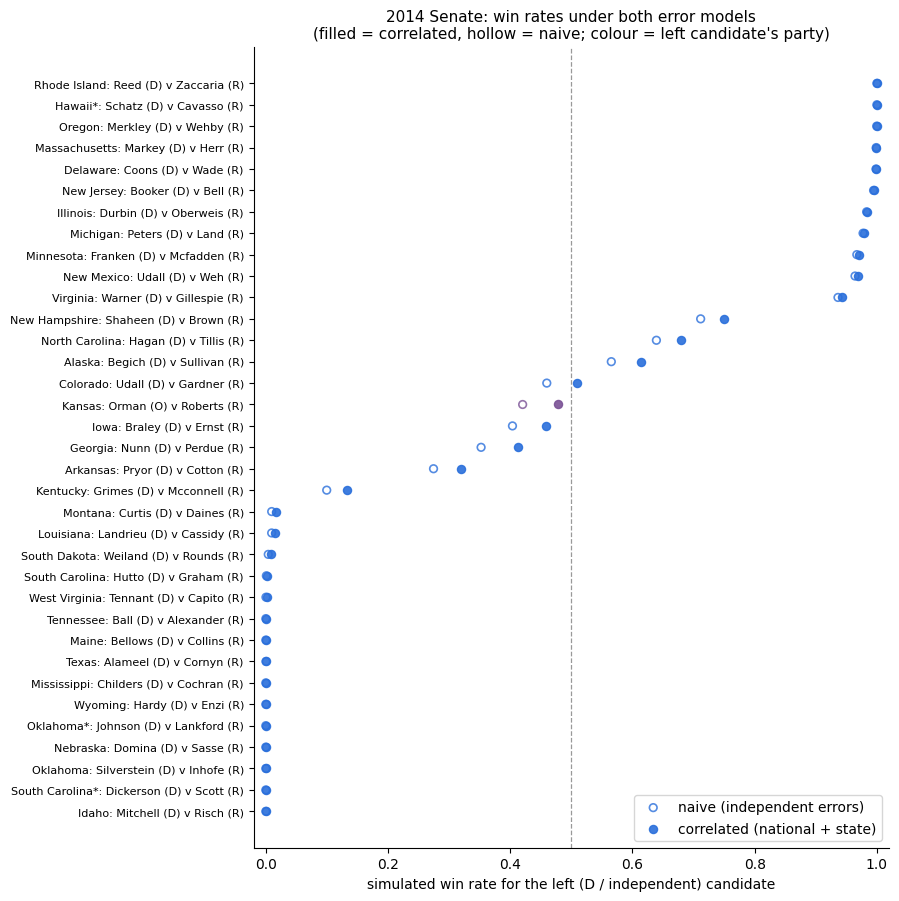

In [8]:
order = test.sort_values("win_corr", ascending=True).reset_index()
fig, ax = plt.subplots(figsize=(8.2, 10.4))
for party, color in PARTY_COLOR.items():
    sub = order[order.left_party == party]
    ax.scatter(sub.win_naive, sub.index, s=30, facecolor="none",
               edgecolor=color, linewidth=1.2, alpha=0.8,
               label="naive (independent errors)" if party == "d" else None)
    ax.scatter(sub.win_corr, sub.index, s=34, color=color, alpha=0.9,
               label="correlated (national + state)" if party == "d" else None)
ax.axvline(0.5, color="0.6", lw=0.9, ls="--")
ax.set_yticks(order.index)
ax.set_yticklabels(order.race_label, fontsize=8)
ax.set(xlabel="simulated win rate for the left (D / independent) candidate",
       xlim=(-0.02, 1.02),
       title="2014 Senate: win rates under both error models\n"
             "(filled = correlated, hollow = naive; colour = left candidate's party)")
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc="lower right")
print("races where the two models disagree most:")
gap = test.assign(g=(test.win_corr - test.win_naive).abs()).nlargest(4, "g")
for _, r in gap.iterrows():
    print(f"  {r.state:12s} corr {r.win_corr:.2f} vs naive {r.win_naive:.2f}"
          f"  (polls {r.pred_margin:+.1f}, actual {r.margin:+.1f})")

actual D seats: 12 (Kansas's Orman excluded — independent)
P(D seats >= 16): correlated 0.33   naive 0.20
P(D seats >= 18): correlated 0.04   naive 0.01
P(D seats <= 12): correlated 0.08   naive 0.09

sigma_nat sensitivity (national error sd 0 / 2 / 4):
  sigma_nat=0: seat sd 1.38, P(D>=18) 0.007, P(D<=12) 0.087
  sigma_nat=2: seat sd 1.64, P(D>=18) 0.042, P(D<=12) 0.081
  sigma_nat=4: seat sd 2.21, P(D>=18) 0.100, P(D<=12) 0.162


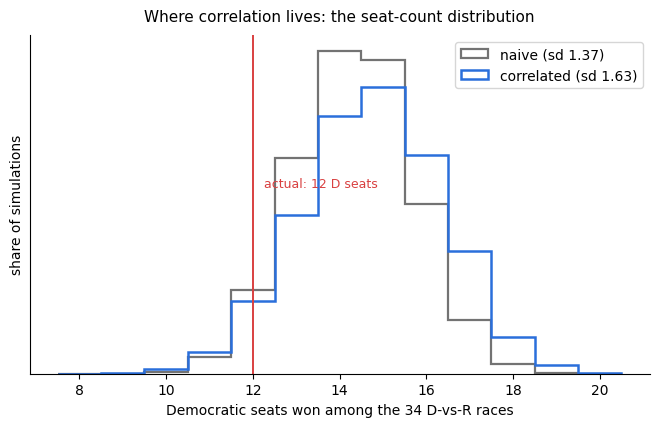

In [9]:
d_mask = (test.left_party == "d").values
seats_c = (margins_c[:, d_mask] > 0).sum(axis=1)
seats_n = (margins_n[:, d_mask] > 0).sum(axis=1)
actual_d_seats = int(((test.left_party == "d") & test.actual_win).sum())

bins = np.arange(7.5, 21.5, 1.0)
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.hist(seats_n, bins=bins, histtype="step", lw=1.6, color="0.45",
        density=True, label=f"naive (sd {seats_n.std():.2f})")
ax.hist(seats_c, bins=bins, histtype="step", lw=1.8, color="#2a6fdb",
        density=True, label=f"correlated (sd {seats_c.std():.2f})")
ax.axvline(actual_d_seats, color="#d94040", lw=1.4)
ax.annotate(f"actual: {actual_d_seats} D seats", (actual_d_seats + 0.25, 0.55),
            xycoords=("data", "axes fraction"), fontsize=9, color="#d94040")
ax.set(xlabel="Democratic seats won among the 34 D-vs-R races",
       ylabel="share of simulations", yticks=[])
ax.legend(loc="upper right")
ax.set_title("Where correlation lives: the seat-count distribution", pad=10)

print(f"actual D seats: {actual_d_seats} (Kansas's Orman excluded — independent)")
for k in (16, 18):
    print(f"P(D seats >= {k}): correlated {(seats_c >= k).mean():.2f}"
          f"   naive {(seats_n >= k).mean():.2f}")
print(f"P(D seats <= {actual_d_seats}): correlated {(seats_c <= actual_d_seats).mean():.2f}"
      f"   naive {(seats_n <= actual_d_seats).mean():.2f}")
print("\nsigma_nat sensitivity (national error sd 0 / 2 / 4):")
for sn in (0.0, 2.0, 4.0):
    nc = rng.normal(NAT_MEAN, sn, SIMS) if sn else np.zeros(SIMS)
    ms = test.pred_margin.values[None, :] + nc[:, None] + noise_c
    ss = (ms[:, d_mask] > 0).sum(axis=1)
    print(f"  sigma_nat={sn:.0f}: seat sd {ss.std():.2f}, "
          f"P(D>=18) {(ss >= 18).mean():.3f}, P(D<=12) {(ss <= actual_d_seats).mean():.3f}")

### Were the probabilities honest?

Two honest ways to score probability forecasts, neither of which the seat
histogram covers. **Per-race**: Brier score and log loss on the 35 races,
where the naive model is *favored by design* — it is more confident on
every favorite, and in 2014 most favorites won. **Jointly**: how surprised
each model was by the seat total it had to swallow — P(D ≤ 12) — where
correlation is supposed to earn its keep.

per-race  Brier:   correlated 0.0542   naive 0.0451
per-race  log loss: correlated 0.1607   naive 0.1412
joint     P(D seats <= 12): correlated 0.083   naive 0.086

realized 2014 national error: -3.4 (model expected +0.9)
the 2014 misses were partly idiosyncratic - opposite signs in safe seats:
                                race_label  pred_margin  margin   err
             Wyoming: Hardy (D) v Enzi (R)        -44.1   -61.1 -17.0
          Arkansas: Pryor (D) v Cotton (R)         -4.4   -17.8 -13.4
     Rhode Island: Reed (D) v Zaccaria (R)         52.9    41.4 -11.5
South Carolina*: Dickerson (D) v Scott (R)        -35.7   -24.5  11.2
      Virginia: Warner (D) v Gillespie (R)         10.9     0.8 -10.0
           Kansas: Orman (O) v Roberts (R)         -1.4   -11.1  -9.7


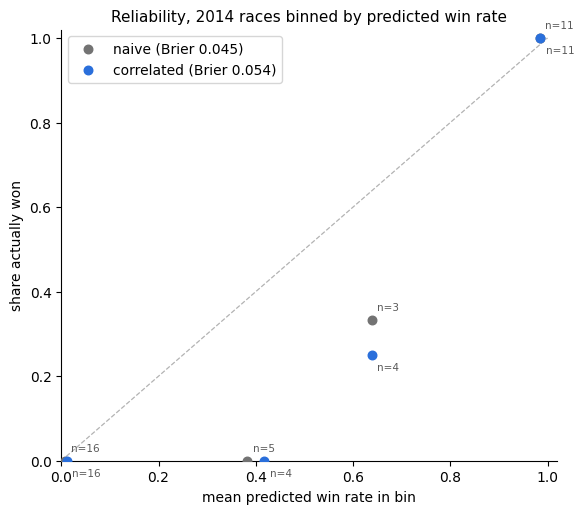

In [10]:
def brier(p, y):
    return float(np.mean((p - y) ** 2))

def logloss(p, y):
    pc = np.clip(p, 1e-4, 1 - 1e-4)
    return float(-np.mean(y * np.log(pc) + (1 - y) * np.log(1 - pc)))

y = test.actual_win.values.astype(float)
print(f"per-race  Brier:   correlated {brier(test.win_corr, y):.4f}"
      f"   naive {brier(test.win_naive, y):.4f}")
print(f"per-race  log loss: correlated {logloss(test.win_corr, y):.4f}"
      f"   naive {logloss(test.win_naive, y):.4f}")
print(f"joint     P(D seats <= 12): correlated {(seats_c <= 12).mean():.3f}"
      f"   naive {(seats_n <= 12).mean():.3f}")

err14 = test.margin - test.pred_margin
print(f"\nrealized 2014 national error: {err14.mean():+.1f}"
      f" (model expected {NAT_MEAN:+.1f})")
print("the 2014 misses were partly idiosyncratic - opposite signs in safe seats:")
e14 = test.assign(err=err14).reindex(err14.abs().sort_values(ascending=False).index)
print(e14[["race_label", "pred_margin", "margin", "err"]].head(6).to_string(index=False))

# reliability: predicted vs realized, binned
fig, ax = plt.subplots(figsize=(6.4, 5.6))
edge = np.array([0, 0.25, 0.5, 0.75, 1.0001])
for col, color, label, dy in [("win_naive", "0.45", "naive", 7),
                              ("win_corr", "#2a6fdb", "correlated", -11)]:
    b = pd.cut(test[col], edge, right=False)
    g = test.groupby(b, observed=True)
    stats = pd.DataFrame({"p": g[col].mean(), "y": g.actual_win.mean(),
                          "n": g.size()}).dropna()
    ax.scatter(stats.p, stats.y, s=38, color=color, zorder=3,
               label=f"{label} (Brier {brier(test[col], y):.3f})")
    for x, yy, n in zip(stats.p, stats.y, stats.n):
        ax.annotate(f"n={int(n)}", (x, yy), fontsize=7.5,
                    xytext=(4, dy), textcoords="offset points", color="0.35")
ax.plot([0, 1], [0, 1], color="0.7", lw=0.9, ls="--")
ax.set(xlabel="mean predicted win rate in bin", ylabel="share actually won",
       xlim=(0, 1.02), ylim=(0, 1.02),
       title="Reliability, 2014 races binned by predicted win rate")
ax.legend(loc="upper left")

## Takeaways

The notebook above does five things in order, and each step prints what it
left on the table:

1. **Build the targets.** 138 Senate races survive the screens ('08–'14:
   34 + 36 + 33 + 35) — walkovers, unopposed incumbents, convention tables
   and two embedded poll tables fall out; runoff seats (GA '08, LA '14) use
   the runoff; non-Democratic lefts (Sanders '12, Orman '14) stay in with
   an explicit party label.
2. **Average the polls.** Surname matching (party codes in the export are
   untrustworthy), one poll instance per pollster-date, two-party margins,
   7-day half-life × √n over the final 21 days. 118 of 138 races get a
   final average — every 2014 race except South Dakota.
3. **Fit the error model on '08–'12.** Incumbent party out-runs polls by
   +1.55; the residual splits into a national component (year means −1.1,
   +1.7, +1.8 → mean +0.9, sd floored at 2.0 after the raw 0.9 estimate
   proved unresolvable with three cycles) and a state component (sd 7.2).
   The implied pairwise correlation between states is only ~0.07 — Senate
   polling error is mostly state noise.
4. **Project 2014.** The correlated model's per-race win rates are more
   humble than the naive ones (North Carolina 0.68 vs 0.64, Alaska 0.61
   vs 0.57, Kansas 0.48 vs 0.42), and the seat distribution fattens
   exactly where correlation should: P(≥ 18 D seats) 3.9% vs 0.9%,
   sd 1.63 vs 1.37 seats.
5. **Score it.** Per-race, naive wins (Brier 0.045 vs 0.054) — partly
   by construction, since correlation buys humility, and 2014's favorites
   mostly won. Jointly it's a wash: both models gave the actual 12-D-seat
   night about the same probability (8.3% vs 8.6%), because 2014's misses
   were *idiosyncratic* — Virginia (−10) and Kansas (−10) ran R-ward while
   safe-seat misses ran the other way (RI −11.5, SC-special +11.2). The
   model's expected national tilt (+0.9 D-side, inherited from 2010/2012)
   was wrong-signed for 2014 (−3.4 realized). A shared national shock is
   not the same as a shared *direction*, and three cycles is a thin reed
   for the sign.

**Caveats that actually move numbers.** The σ_nat floor (2.0) is a judgment
call — the sensitivity table shows the tails at 0 and 4. Poll MoE and
pollster house-effects are ignored; √n and recency carry all the weighting.
The incumbency bump is one pooled D-vs-R contrast, not a per-race effect.
Kansas's margin model predicts a two-party Orman-Roberts share, while the
race also contained a Libertarian and a quit-but-still-listed Democrat. And
the 2014 map's biggest single miss (Arkansas, polls −4.4 vs −17.8) was a
late-break the two-level structure has no vocabulary for — that's state
noise doing state-noise things.